# Data preprocessing

Raw data almost never goes straight into a model. This notebook covers the cleaning and transformation
steps from the MLP preprocessing colabs (parts 1 and 2, plus the separate KNN imputer one):

1. Missing values (`SimpleImputer`, `KNNImputer`)
2. Feature scaling (`MinMaxScaler`, `StandardScaler`, `MaxAbsScaler`, `RobustScaler`)
3. Categorical features (one-hot, ordinal, label encoding)
4. Other transformations (dict vectorizing, log transforms, polynomial features, binning)
5. Imbalanced classes (under/oversampling, SMOTE)

Feature selection, PCA and pipelines are in the next notebook.

Datasets used: heart disease, abalone, wine quality and iris from the UCI repository (read straight from
their URLs), plus some small made-up arrays.

In [1]:
# imbalanced-learn is needed for section 5. Colab usually has it, uncomment if the import fails
# %pip install -q imbalanced-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Missing values

Most sklearn models refuse to train if there's a `NaN` anywhere in `X`. The options are to drop the rows
(lose data), drop the column (lose a feature), or **impute**: fill each gap with a sensible estimate.

### Heart disease data

303 patients from the Cleveland clinic. Columns:

| column | meaning |
|---|---|
| age, sex | sex: 1 = male, 0 = female |
| cp | chest pain type (1-4) |
| trestbps | resting blood pressure |
| chol | serum cholesterol (mg/dl) |
| fbs | fasting blood sugar > 120 mg/dl (1/0) |
| restecg | resting ECG result (0, 1, 2) |
| thalach | max heart rate achieved |
| exang | exercise induced angina (1/0) |
| oldpeak | ST depression from exercise relative to rest |
| slope | slope of peak exercise ST segment (1-3) |
| ca | number of major vessels coloured by fluoroscopy (0-3) |
| thal | 3 = normal, 6 = fixed defect, 7 = reversible defect |
| num | diagnosis, 0 = no disease, 1-4 = disease |

In [3]:
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
        'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
heart_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

heart = pd.read_csv(heart_url, header=None, names=cols)
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  num       303 non-null    float64
dtypes: float64(12), str(2)
memory usage: 33.3 KB


In [4]:
heart.isna().sum().sum()

np.int64(0)

No `NaN`s, but `ca` and `thal` came in as `object` (text) even though they should be numbers.
That usually means there's some placeholder string in there.

In [5]:
print("ca:  ", heart['ca'].unique())
print("thal:", heart['thal'].unique())

ca:   <StringArray>
['0.0', '3.0', '2.0', '1.0', '?']
Length: 5, dtype: str
thal: <StringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str


In [6]:
(heart[['ca', 'thal']] == '?').sum()

ca      4
thal    2
dtype: int64

The dataset uses `?` for missing. Swap it for `NaN` and convert the two columns to numbers.
(`pd.read_csv(..., na_values='?')` does the same thing while loading.)

In [7]:
heart = heart.replace('?', np.nan)
heart[['ca', 'thal']] = heart[['ca', 'thal']].astype(float)
heart.isna().sum()[lambda s: s > 0]

ca      4
thal    2
dtype: int64

### SimpleImputer

Fills each column using one statistic of that column:

| strategy | fills with | works on |
|---|---|---|
| `mean` (default) | column mean | numbers |
| `median` | column median | numbers |
| `most_frequent` | mode | numbers or strings |
| `constant` | `fill_value` | numbers or strings |

`missing_values` says what counts as missing (default `np.nan`, but it can be `-1`, `'?'`, `None` ...).

For `ca` and `thal` the mean is a bit odd since they're really categories (you'd get `ca = 0.67`), so
`most_frequent` is a better choice here.

In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
heart_imputed = imputer.fit_transform(heart)

heart_imputed.shape, np.isnan(heart_imputed).sum()

((303, 14), np.int64(0))

In [9]:
imputer.statistics_[[11, 12]]    # values used to fill ca and thal

array([0., 3.])

`add_indicator=True` also adds a 0/1 column for every feature that had gaps. Sometimes *whether* a value
was missing is itself useful information. With `set_output(transform='pandas')` the result is a DataFrame
with proper column names.

In [10]:
imputer = SimpleImputer(strategy='most_frequent', add_indicator=True).set_output(transform='pandas')
heart_ind = imputer.fit_transform(heart)

heart_ind.shape     # 14 original + 2 indicator columns

(303, 16)

In [11]:
heart_ind[heart_ind['missingindicator_ca'] == 1][['ca', 'thal', 'missingindicator_ca', 'missingindicator_thal']]

,ca,thal,missingindicator_ca,missingindicator_thal
166,0.0,3.0,1.0,0.0
192,0.0,7.0,1.0,0.0
287,0.0,7.0,1.0,0.0
302,0.0,3.0,1.0,0.0


### Missing values that aren't NaN

Here `-1` marks a missing value:

In [12]:
X1 = np.array([[1,  2,  3],
               [6,  0, -1],
               [3, -1,  4]])

SimpleImputer(missing_values=-1, strategy='mean').fit_transform(X1)

array([[1. , 2. , 3. ],
       [6. , 0. , 3.5],
       [3. , 1. , 4. ]])

Column 2: mean of (2, 0) = 1. Column 3: mean of (3, 4) = 3.5.

### Mixed numbers and text

In the original colab this was a NumPy array, which turns every value into a string. A DataFrame keeps
the types, and different columns can get different strategies.

In [13]:
people = pd.DataFrame({
    'country': ['France', 'Spain', 'Germany', 'Spain', 'Germany',
                'France', 'Spain', 'France', np.nan, 'France'],
    'age':     [44, 27, 30, 38, 40, 35, np.nan, 48, 50, 37],
    'salary':  [72000, 48000, 54000, 61000, np.nan, 58000, 52000, 79000, 83000, 67000],
})
people

,country,age,salary
0,France,44.0,72000.0
1,Spain,27.0,48000.0
2,Germany,30.0,54000.0
3,Spain,38.0,61000.0
4,Germany,40.0,NaN
5,France,35.0,58000.0
6,Spain,NaN,52000.0
7,France,48.0,79000.0
8,NaN,50.0,83000.0
9,France,37.0,67000.0


In [14]:
filled = people.copy()
filled[['age', 'salary']] = SimpleImputer(strategy='mean').fit_transform(people[['age', 'salary']])
filled[['country']] = SimpleImputer(strategy='most_frequent').fit_transform(people[['country']])
filled

,country,age,salary
0,France,44.000000,72000.000000
1,Spain,27.000000,48000.000000
2,Germany,30.000000,54000.000000
3,Spain,38.000000,61000.000000
4,Germany,40.000000,63777.777778
5,France,35.000000,58000.000000
6,Spain,38.777778,52000.000000
7,France,48.000000,79000.000000
8,France,50.000000,83000.000000
9,France,37.000000,67000.000000


(`ColumnTransformer` in the next notebook does this in one object instead of two separate calls.)

### KNNImputer

Instead of a single column statistic, look at the `k` rows most similar to the one with the gap and
average their values. This uses the other features, so it's usually a better guess than the overall mean.

The catch: how do you measure distance between rows that themselves have missing values?

#### nan_euclidean distance

Ignore any coordinate that's missing in either row, compute the normal Euclidean distance on the rest,
then scale it up to make up for the dropped coordinates:

$$
d(a, b) = \sqrt{w \cdot \sum_{i \,\in\, \text{present}} (a_i - b_i)^2},
\qquad
w = \frac{\text{total number of coordinates}}{\text{number present in both}}
$$

Example data, 4 rows and 4 columns:

| | c0 | c1 | c2 | c3 |
|---|---|---|---|---|
| r0 | 3 | NaN | 2 | 0 |
| r1 | 5 | 4 | 1 | 5 |
| r2 | 6 | 5 | 4 | NaN |
| r3 | 6 | 7 | 7 | 5 |

**r0 to r2**: only c0 and c2 are present in both, so w = 4/2 = 2

$$d = \sqrt{2 \left[(3-6)^2 + (2-4)^2\right]} = \sqrt{2 \cdot 13} = \sqrt{26} \approx 5.099$$

**r0 to r1**: c0, c2, c3 are present, so w = 4/3

$$d = \sqrt{\tfrac{4}{3} \left[(3-5)^2 + (2-1)^2 + (0-5)^2\right]} = \sqrt{\tfrac{4}{3} \cdot 30} = \sqrt{40} \approx 6.325$$

In [15]:
from sklearn.metrics.pairwise import nan_euclidean_distances

X = np.array([[3, np.nan, 2, 0],
              [5, 4,      1, 5],
              [6, 5,      4, np.nan],
              [6, 7,      7, 5]])

nan_euclidean_distances(X[[0]], X[[2]]), nan_euclidean_distances(X[[0]], X[[1]])

(array([[5.09901951]]), array([[6.32455532]]))

In [16]:
# all pairs
nan_euclidean_distances(X).round(3)

array([[0.   , 6.325, 5.099, 8.869],
       [6.325, 0.   , 3.83 , 6.782],
       [5.099, 3.83 , 0.   , 4.163],
       [8.869, 6.782, 4.163, 0.   ]])

Checking the first one by hand in code:

In [17]:
a, b = X[0], X[2]
both = ~np.isnan(a) & ~np.isnan(b)
w = len(a) / both.sum()
np.sqrt(w * ((a[both] - b[both]) ** 2).sum())

np.float64(5.0990195135927845)

#### Filling r0's missing c1

Distances from r0 (first row of the matrix above): r2 = 5.099, r1 = 6.325, r3 = 8.869.
With `n_neighbors=2` the neighbours are **r2** (c1 = 5) and **r1** (c1 = 4).

* `weights="uniform"`: plain average, (5 + 4) / 2 = **4.5**
* `weights="distance"`: weight each neighbour by 1 / distance, so closer rows count more

$$
\frac{5 \cdot \tfrac{1}{5.099} + 4 \cdot \tfrac{1}{6.325}}{\tfrac{1}{5.099} + \tfrac{1}{6.325}} \approx 4.554
$$

(This `weights` parameter has nothing to do with the `w` in the distance formula.)

In [18]:
from sklearn.impute import KNNImputer

KNNImputer(n_neighbors=2, weights="uniform").fit_transform(X)

array([[3. , 4.5, 2. , 0. ],
       [5. , 4. , 1. , 5. ],
       [6. , 5. , 4. , 5. ],
       [6. , 7. , 7. , 5. ]])

In [19]:
KNNImputer(n_neighbors=2, weights="distance").fit_transform(X)

array([[3.        , 4.55364064, 2.        , 0.        ],
       [5.        , 4.        , 1.        , 5.        ],
       [6.        , 5.        , 4.        , 5.        ],
       [6.        , 7.        , 7.        , 5.        ]])

In [20]:
d_r2, d_r1 = 5.0990195, 6.3245553
(5 / d_r2 + 4 / d_r1) / (1 / d_r2 + 1 / d_r1)

4.553640643207414

r2's missing c3 gets filled the same way, using its own nearest neighbours.

Because KNNImputer is distance based, columns with large values dominate the distance. Scale the data
first (section 2) when the features are on different scales.

Back on the heart data:

In [21]:
heart_knn = KNNImputer(n_neighbors=5).set_output(transform='pandas').fit_transform(heart)
heart_knn.loc[heart['ca'].isna() | heart['thal'].isna(), ['age', 'chol', 'ca', 'thal']]

,age,chol,ca,thal
87,53.0,216.0,0.0,5.4
166,52.0,223.0,0.6,3.0
192,43.0,247.0,0.6,7.0
266,52.0,204.0,0.0,3.8
287,58.0,220.0,1.6,7.0
302,38.0,175.0,0.0,3.0


These come out as decimals (an average of 5 neighbours). Since `ca` and `thal` are categories you'd
round them afterwards, or use `most_frequent` like above.

---

## 2. Feature scaling

If one feature is in the thousands and another is between 0 and 1:

* distance-based models (KNN, K-means, SVM) are dominated by the big feature
* gradient descent (linear/logistic regression, neural nets) converges slowly because the loss surface is stretched
* regularisation penalises coefficients unevenly

Tree-based models split on one feature at a time and don't care about scale.

Small example with three features on very different ranges:

In [22]:
rng = np.random.RandomState(42)
X = np.column_stack([rng.randint(1, 20, 20),
                     rng.randint(10, 200, 20),
                     rng.randint(100, 2000, 20)]).astype(float)

print("mean:", X.mean(axis=0).round(1))
print("std: ", X.std(axis=0).round(1))

mean: [   8.9  114.2 1005.2]
std:  [  4.9  61.5 569.3]


### Abalone data

Predicting the age of abalone (a sea snail) from physical measurements. `Rings` + 1.5 gives the age in
years, so it's the target.

| column | |
|---|---|
| Sex | M, F, or I (infant) |
| Length, Diameter, Height | mm |
| Whole / Shucked / Viscera / Shell weight | grams |
| Rings | target |

In [23]:
cols = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight',
        'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']
abalone_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'

abalone = pd.read_csv(abalone_url, header=None, names=cols)
abalone.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Scaling only applies to numeric columns. `Sex` is categorical (dealt with in section 3), and `Rings`
is the target, so both come out of the feature matrix.

The original colab mapped Sex to 1/2/3 and scaled it along with everything else. That gives the model a
fake ordering (infant > female > male), so I've left it out here.

In [24]:
y = abalone['Rings']
X = abalone.drop(columns=['Sex', 'Rings'])
X.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Length,0.523992,0.120093,0.0750,0.8150
Diameter,0.407881,0.099240,0.0550,0.6500
Height,0.139516,0.041827,0.0000,1.1300
Whole weight,0.828742,0.490389,0.0020,2.8255
Shucked weight,0.359367,0.221963,0.0010,1.4880
Viscera weight,0.180594,0.109614,0.0005,0.7600
Shell weight,0.238831,0.139203,0.0015,1.0050


The ranges are different (Whole weight goes up to 2.8, Height mostly sits around 0.14), though not as
extreme as the toy example above. Height also has a couple of odd values far above the rest.

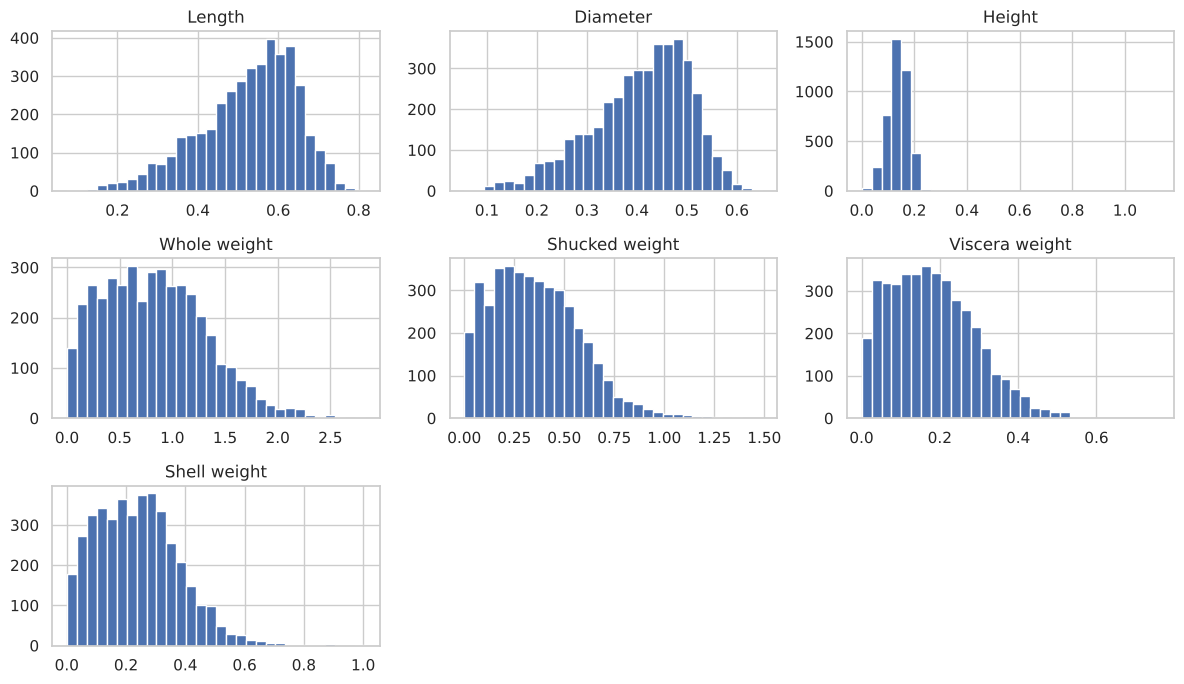

In [25]:
X.hist(figsize=(12, 7), bins=30)
plt.tight_layout()
plt.show()

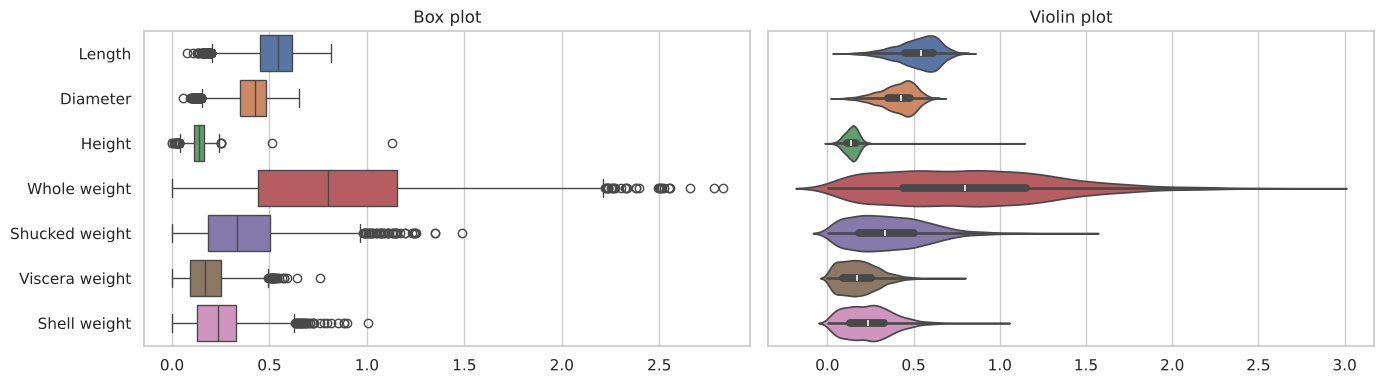

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=X, orient='h', ax=axes[0])
axes[0].set_title('Box plot')
sns.violinplot(data=X, orient='h', density_norm='width', ax=axes[1])
axes[1].set_title('Violin plot')
axes[1].set_yticklabels([])
plt.tight_layout()
plt.show()

A box plot shows the quartiles and flags outliers (points beyond 1.5 x IQR). A violin plot shows a
smoothed density (KDE) instead, so you can see the shape of the distribution.

### MaxAbsScaler

Divides by the largest absolute value, so everything ends up in [-1, 1]:

$$x' = \frac{x}{\max |x|}$$

It doesn't shift the data, so zeros stay zeros. That makes it the one to use on sparse data.

In [27]:
from sklearn.preprocessing import MaxAbsScaler

x = np.array([4, 2, 5, -2, -100]).reshape(-1, 1)
MaxAbsScaler().fit_transform(x).ravel()

array([ 0.04,  0.02,  0.05, -0.02, -1.  ])

Note how the single -100 squashes everything else close to 0. Same problem with min-max below.

### MinMaxScaler (normalisation)

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Maps each feature to [0, 1].

In [28]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

X_minmax = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)
X_minmax.agg(['min', 'max', 'mean', 'std']).T.round(3)

,min,max,mean,std
Length,0.0,1.0,0.607,0.162
Diameter,0.0,1.0,0.593,0.167
Height,0.0,1.0,0.123,0.037
Whole weight,0.0,1.0,0.293,0.174
Shucked weight,0.0,1.0,0.241,0.149
Viscera weight,0.0,1.0,0.237,0.144
Shell weight,0.0,1.0,0.237,0.139


### StandardScaler (standardisation)

$$x' = \frac{x - \mu}{\sigma}$$

Mean 0 and standard deviation 1 for every feature. No fixed range, but much less sensitive to a single
extreme value than min-max. This is the default choice most of the time.

In [29]:
X_std = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
X_std.agg(['mean', 'std']).T.round(3)

,mean,std
Length,-0.0,1.0
Diameter,-0.0,1.0
Height,0.0,1.0
Whole weight,0.0,1.0
Shucked weight,-0.0,1.0
Viscera weight,0.0,1.0
Shell weight,0.0,1.0


### RobustScaler

Not in the course colab, but worth knowing: subtracts the median and divides by the IQR, so outliers
barely affect the scaling.

In [30]:
X_robust = pd.DataFrame(RobustScaler().fit_transform(X), columns=X.columns)

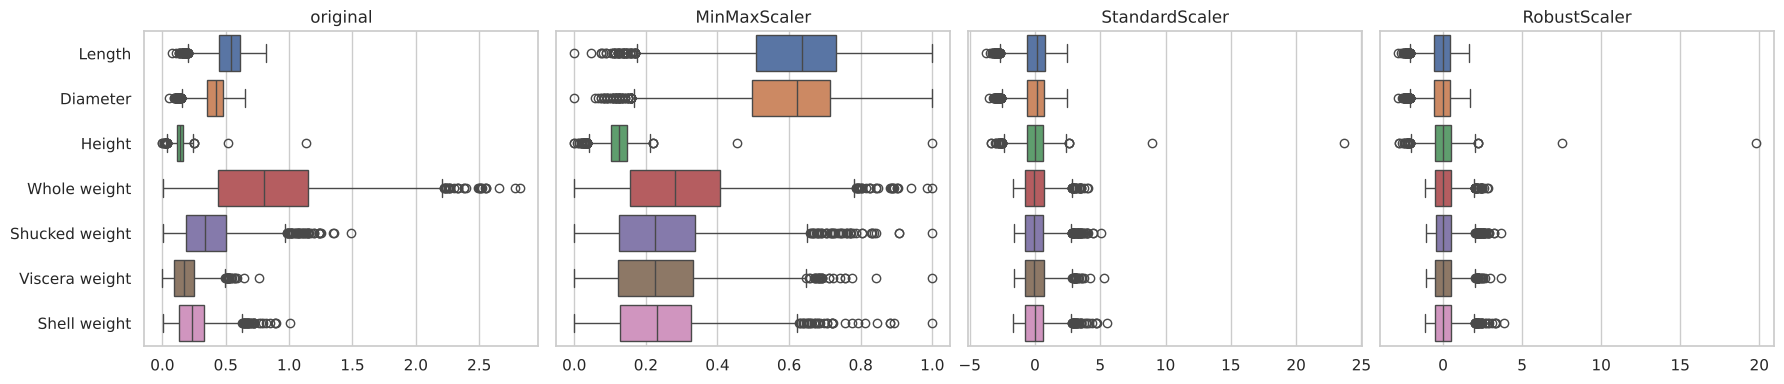

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, data, title in zip(axes, [X, X_minmax, X_std, X_robust],
                           ['original', 'MinMaxScaler', 'StandardScaler', 'RobustScaler']):
    sns.boxplot(data=data, orient='h', ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

All three put the features on comparable scales. Look at Height: it has two extreme outliers, and after
min-max the rest of its values are squeezed into a narrow band near the bottom.

### Fit on training data only

The scaler's mean/std (or min/max) are learned values. They should come from the **training** set and then
be reused on the test set. Fitting on the full dataset lets information from the test set leak into
training.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler().fit(X_train)       # learn from train
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)          # reuse on test, no refit

X_test_s.mean(axis=0).round(2)               # close to 0, but not exactly

array([-0.08, -0.08, -0.07, -0.1 , -0.09, -0.09, -0.09])

Pipelines (next notebook) take care of this automatically.

---

## 3. Categorical features

Models need numbers. The obvious approach, numbering the categories, is a problem for most features:

| state | code |
|---|---|
| Punjab | 1 |
| Rajasthan | 2 |
| Haryana | 3 |

This tells the model Haryana > Rajasthan > Punjab, and that Haryana is "3 times" Punjab, which means
nothing. For categories with no natural order, use **one-hot encoding**: one 0/1 column per category.

| state | is_Punjab | is_Rajasthan | is_Haryana |
|---|---|---|---|
| Punjab | 1 | 0 | 0 |
| Rajasthan | 0 | 1 | 0 |
| Haryana | 0 | 0 | 1 |

### OneHotEncoder

In [33]:
from sklearn.preprocessing import OneHotEncoder

colours = np.array([['red'], ['green'], ['blue'], ['green']])

enc = OneHotEncoder(sparse_output=False)
enc.fit_transform(colours)

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [34]:
enc.categories_, enc.get_feature_names_out()

([array(['blue', 'green', 'red'], dtype='<U5')],
 array(['x0_blue', 'x0_green', 'x0_red'], dtype=object))

Columns are in alphabetical order (blue, green, red). The encoder expects 2D input, hence the `[[...]]`.

`sparse_output` used to be called `sparse` (renamed in sklearn 1.2). By default the output is a sparse
matrix, which saves memory when there are many categories.

A category that wasn't seen during `fit` raises an error unless `handle_unknown='ignore'` is set, in which
case it becomes all zeros:

In [35]:
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(colours)
enc.transform([['yellow'], ['red']])

array([[0., 0., 0.],
       [0., 0., 1.]])

On the iris labels:

In [36]:
iris_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
iris = pd.read_csv(iris_url, header=None,
                   names=['sepal length', 'sepal width', 'petal length', 'petal width', 'label'])
iris['label'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [37]:
onehot = OneHotEncoder().fit_transform(iris[['label']])
onehot          # sparse

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 150 stored elements and shape (150, 3)>

In [38]:
onehot.toarray()[[0, 50, 100]]    # one row from each class

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### pd.get_dummies

The pandas way. Handy for quick analysis, but it doesn't remember the categories, so the train and test
sets can end up with different columns. For anything that goes into a model, `OneHotEncoder` is safer.

In [39]:
pd.get_dummies(abalone, columns=['Sex'], prefix='sex', dtype=int).head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,sex_F,sex_I,sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,1,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0,1,0


### OrdinalEncoder

For categories that **do** have an order (low < medium < high, school < college < postgrad), integer
codes are the right thing. Pass the order explicitly, otherwise it's alphabetical.

In [40]:
from sklearn.preprocessing import OrdinalEncoder

sizes = pd.DataFrame({'size': ['medium', 'small', 'large', 'small', 'large']})

OrdinalEncoder().fit_transform(sizes).ravel()        # alphabetical: large=0, medium=1, small=2

array([1., 2., 0., 2., 0.])

In [41]:
OrdinalEncoder(categories=[['small', 'medium', 'large']]).fit_transform(sizes).ravel()

array([1., 0., 2., 0., 2.])

### LabelEncoder

Same idea as `OrdinalEncoder`, but for the **target** `y` (it takes 1D input). Most sklearn classifiers
accept string labels directly anyway, so this is mostly for libraries that need integer classes.

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_iris = le.fit_transform(iris['label'])
le.classes_, np.bincount(y_iris)

(array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object),
 array([50, 50, 50]))

In [43]:
le.inverse_transform([0, 2])

array(['Iris-setosa', 'Iris-virginica'], dtype=object)

### MultiLabelBinarizer

For when each sample can have several labels. One column per label, 1 if the sample has it.

In [44]:
from sklearn.preprocessing import MultiLabelBinarizer

movie_genres = [{'action', 'comedy'},
                {'comedy'},
                {'action', 'thriller'},
                {'science-fiction', 'action', 'thriller'}]

mlb = MultiLabelBinarizer()
pd.DataFrame(mlb.fit_transform(movie_genres), columns=mlb.classes_)

,action,comedy,science-fiction,thriller
0,1,1,0,0
1,0,1,0,0
2,1,0,0,1
3,1,0,1,1


---

## 4. Other transformations

### DictVectorizer

For data that comes as a list of dicts (JSON, API responses). Numbers pass through, and string values
get one-hot encoded automatically.

In [45]:
from sklearn.feature_extraction import DictVectorizer

children = [{'age': 4, 'height': 96.0, 'city': 'Pune'},
            {'age': 1, 'height': 73.9, 'city': 'Delhi'},
            {'age': 3, 'height': 88.9, 'city': 'Pune'},
            {'age': 2, 'height': 81.6}]           # missing key -> 0

dv = DictVectorizer(sparse=False)
pd.DataFrame(dv.fit_transform(children), columns=dv.get_feature_names_out())

,age,city=Delhi,city=Pune,height
0,4.0,0.0,1.0,96.0
1,1.0,1.0,0.0,73.9
2,3.0,0.0,1.0,88.9
3,2.0,0.0,0.0,81.6


### add_dummy_feature

Adds a column of 1s at the front. That's the bias/intercept column when writing linear regression by hand
as $y = Xw$.

In [46]:
from sklearn.preprocessing import add_dummy_feature

add_dummy_feature(np.array([[7, 1], [1, 8], [2, 0], [9, 6]]))

array([[1., 7., 1.],
       [1., 1., 8.],
       [1., 2., 0.],
       [1., 9., 6.]])

### FunctionTransformer (custom transforms)

Wraps any function as a transformer so it can be used in a pipeline. Common use: a log transform for
right-skewed features.

Red wine quality data (1599 wines, 11 chemical measurements, quality score 0-10):

In [47]:
wine_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
wine = pd.read_csv(wine_url, sep=';')
wine.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [48]:
from sklearn.preprocessing import FunctionTransformer

log_tf = FunctionTransformer(np.log1p)      # log(1 + x), safe when x = 0
wine_X = wine.drop(columns='quality')
wine_log = pd.DataFrame(log_tf.fit_transform(wine_X), columns=wine_X.columns)

wine_log.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
fixed acidity,2.215842,0.178100,1.722767,2.827314
volatile acidity,0.417173,0.114926,0.113329,0.947789
citric acid,0.228147,0.152423,0.000000,0.693147
residual sugar,1.218131,0.269969,0.641854,2.803360
chlorides,0.083038,0.038991,0.011929,0.476855
free sulfur dioxide,2.639013,0.623790,0.693147,4.290459
total sulfur dioxide,3.634750,0.682575,1.945910,5.669881
density,0.691519,0.000945,0.688170,0.694990
pH,1.460557,0.035760,1.319086,1.611436
sulphates,0.501073,0.093731,0.285179,1.098612


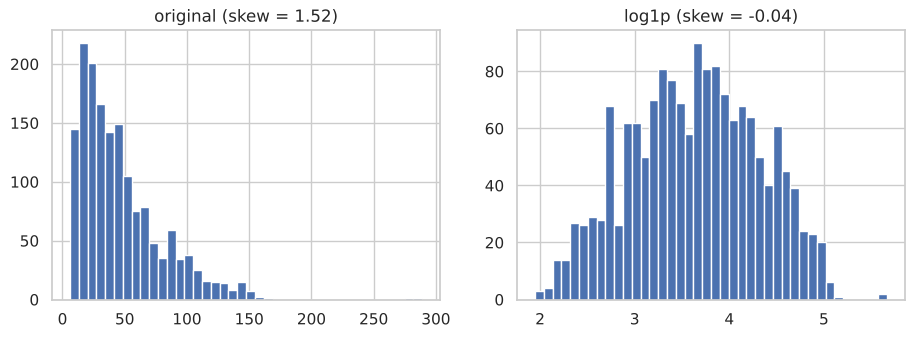

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
wine_X['total sulfur dioxide'].hist(bins=40, ax=axes[0])
axes[0].set_title(f"original (skew = {wine_X['total sulfur dioxide'].skew():.2f})")
wine_log['total sulfur dioxide'].hist(bins=40, ax=axes[1])
axes[1].set_title(f"log1p (skew = {wine_log['total sulfur dioxide'].skew():.2f})")
plt.show()

`total sulfur dioxide` went from a long right tail (6 to 289) to something much more symmetric (about
1.9 to 5.7).

### PolynomialFeatures

Generates all products of features up to a given degree. For `[a, b]` with degree 2:
$[1, a, b, a^2, ab, b^2]$. Lets a linear model fit curves.

In [50]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
poly.fit_transform([[2, 3]]), poly.get_feature_names_out(['a', 'b'])

(array([[1., 2., 3., 4., 6., 9.]]),
 array(['1', 'a', 'b', 'a^2', 'a b', 'b^2'], dtype=object))

In [51]:
poly = PolynomialFeatures(degree=2)
wine_poly = poly.fit_transform(wine_X)
wine_X.shape, wine_poly.shape

((1599, 11), (1599, 78))

In [52]:
poly.get_feature_names_out()[:20]

array(['1', 'fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'fixed acidity^2', 'fixed acidity volatile acidity',
       'fixed acidity citric acid', 'fixed acidity residual sugar',
       'fixed acidity chlorides', 'fixed acidity free sulfur dioxide',
       'fixed acidity total sulfur dioxide', 'fixed acidity density'],
      dtype=object)

11 features become 78: 1 bias + 11 originals + 11 squares + 55 pairwise products. This grows fast with
degree, so it's easy to end up with more features than samples. `interaction_only=True` skips the squares,
`include_bias=False` skips the column of 1s.

### KBinsDiscretizer (binning)

Turns a continuous feature into bins. Can help a linear model pick up non-linear patterns, and makes
the feature more robust to outliers.

In [53]:
from sklearn.preprocessing import KBinsDiscretizer

kb = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
chlorides_bin = kb.fit_transform(wine[['chlorides']])

kb.bin_edges_[0].round(3)

array([0.012, 0.067, 0.076, 0.082, 0.094, 0.611])

In [54]:
pd.Series(chlorides_bin.ravel()).value_counts().sort_index()   # quantile -> roughly equal counts

0.0    297
1.0    319
2.0    298
3.0    351
4.0    334
Name: count, dtype: int64

`strategy='uniform'` makes equal-width bins instead, and `encode='onehot'` (the default) returns one
0/1 column per bin as a sparse matrix:

In [55]:
KBinsDiscretizer(n_bins=10, encode='onehot').fit_transform(wine[['chlorides']]).toarray()[:5]

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

---

## 5. Imbalanced data

When one class is much rarer than the other (fraud, rare diseases), a model can get high accuracy by
always predicting the majority class. Two main fixes at the data level:

* **undersampling** - throw away some majority-class samples
* **oversampling** - repeat or synthesise minority-class samples

Both come from the `imbalanced-learn` (`imblearn`) library.

A synthetic dataset with a 99:1 split:

In [56]:
from collections import Counter
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0, n_clusters_per_class=1,
                           weights=[0.99], flip_y=0, random_state=100)
np.bincount(y)

array([9900,  100])

`weights=[0.99]` puts 99% of the samples in class 0, and `flip_y=0` stops sklearn from randomly
flipping some labels (which would change the ratio).

In [57]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

X_under, y_under = RandomUnderSampler(random_state=0).fit_resample(X, y)
X_over, y_over = RandomOverSampler(random_state=0).fit_resample(X, y)
X_smote, y_smote = SMOTE(random_state=0).fit_resample(X, y)

for name, labels in [('original', y), ('undersampled', y_under),
                     ('random oversampled', y_over), ('SMOTE', y_smote)]:
    print(f"{name:20s}", {int(k): v for k, v in sorted(Counter(labels).items())})

original             {0: 9900, 1: 100}
undersampled         {0: 100, 1: 100}
random oversampled   {0: 9900, 1: 9900}
SMOTE                {0: 9900, 1: 9900}


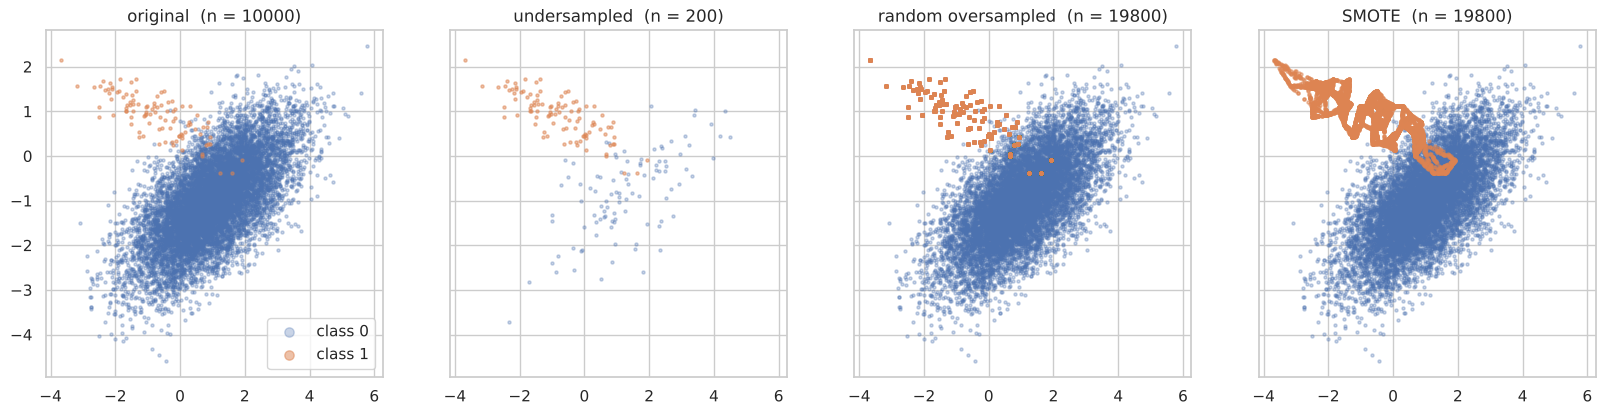

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharex=True, sharey=True)
for ax, (Xs, ys, title) in zip(axes, [(X, y, 'original'), (X_under, y_under, 'undersampled'),
                                      (X_over, y_over, 'random oversampled'), (X_smote, y_smote, 'SMOTE')]):
    ax.scatter(Xs[ys == 0, 0], Xs[ys == 0, 1], s=5, alpha=0.3, label='class 0')
    ax.scatter(Xs[ys == 1, 0], Xs[ys == 1, 1], s=5, alpha=0.5, label='class 1')
    ax.set_title(f"{title}  (n = {len(ys)})")
axes[0].legend(markerscale=3)
plt.show()

* **Undersampling** keeps only 100 of the 9900 majority samples. Balanced, but most of the data is gone.
* **Random oversampling** copies the 100 minority points until there are 9900. The plot looks the same
  as the original because the copies sit exactly on top of each other, which encourages overfitting.
* **SMOTE** creates *new* points on the lines between a minority sample and its nearest minority-class
  neighbours, which fills in the minority region instead of stacking duplicates.

### On a real dataset

Wine quality is heavily imbalanced: most wines are rated 5 or 6.

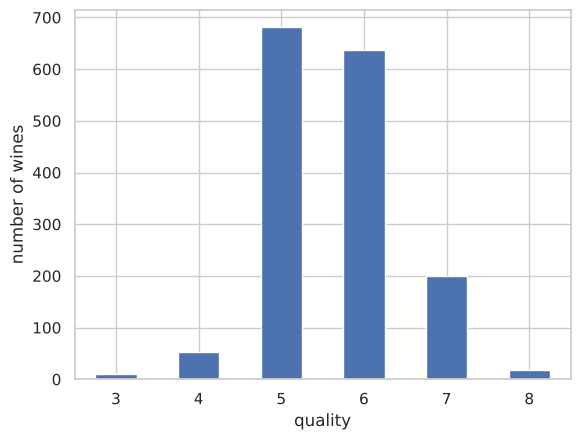

In [59]:
wine['quality'].value_counts().sort_index().plot.bar(rot=0)
plt.xlabel('quality'); plt.ylabel('number of wines')
plt.show()

In [60]:
X_w, y_w = wine.drop(columns='quality'), wine['quality']

_, y_rus = RandomUnderSampler(random_state=0).fit_resample(X_w, y_w)
_, y_sm = SMOTE(random_state=0).fit_resample(X_w, y_w)

pd.DataFrame({'original': y_w.value_counts(),
              'undersampled': y_rus.value_counts(),
              'SMOTE': y_sm.value_counts()}).sort_index()

,original,undersampled,SMOTE
quality,,,
3,10,10,681
4,53,10,681
5,681,10,681
6,638,10,681
7,199,10,681
8,18,10,681


Undersampling cuts every class down to 10 (the size of class 3), leaving 60 wines out of 1599. SMOTE brings
every class up to 681, adding 2487 synthetic rows.

Things to keep in mind:

* resample the **training set only**, never the test set, otherwise the evaluation is on fake data
* for imbalanced problems, look at precision/recall/F1 rather than accuracy
* many sklearn classifiers have `class_weight='balanced'`, which is often enough without resampling
* SMOTE variants in imblearn: `BorderlineSMOTE`, `SVMSMOTE`, `ADASYN`, and `SMOTENC` for data with categorical columns

## References

* [sklearn preprocessing guide](https://scikit-learn.org/stable/modules/preprocessing.html)
* [sklearn imputation guide](https://scikit-learn.org/stable/modules/impute.html)
* [imbalanced-learn docs](https://imbalanced-learn.org/stable/)
* UCI datasets: [heart disease](https://archive.ics.uci.edu/dataset/45/heart+disease),
  [abalone](https://archive.ics.uci.edu/dataset/1/abalone),
  [wine quality](https://archive.ics.uci.edu/dataset/186/wine+quality),
  [iris](https://archive.ics.uci.edu/dataset/53/iris)